In [1]:
import torch

def print_gpu_available_information():
    print("Number of GPU: ", torch.cuda.device_count())
    print("GPU Name: ", torch.cuda.get_device_name())

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)

print_gpu_available_information()

Number of GPU:  1
GPU Name:  NVIDIA GeForce RTX 3080 Ti
Using device: cuda


## Part 1: EDA 
Exploring and cleaning datasets
Objective: To save a cleaned dataset for training process.

In [1]:
from eda_utils import load_and_concatenate_datasets, inspect_missing_and_constant
import os

# Folder and filenames
folder_path = 'datasets'
filenames = ['metasploitable-2.csv', 'OVS.csv', 'Normal_data.csv']

# Load datasets
df_raw = load_and_concatenate_datasets(folder_path, filenames)

# Normalize labels to collapse duplicates (strip, collapse spaces, remove zero-width chars)
df_raw['Label'] = (
    df_raw['Label']
    .astype(str)
    .str.replace(r"[\u200b\u200c\u200d\ufeff]", "", regex=True)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)
print("Unique labels after normalization:", sorted(df_raw['Label'].unique()))

# Remove old encoder so it can be rebuilt with cleaned labels
encoder_path = 'encoders/label_encoder.pkl'
if os.path.exists(encoder_path):
    os.remove(encoder_path)
    print(f"Removed old label encoder at {encoder_path} (will rebuild)")

# Inspect missing/constant
summary = inspect_missing_and_constant(df_raw)

print("Columns with NaNs:")
print(summary['nan_count'][summary['nan_count'] > 0])

print("\nColumns with Infs:")
print(summary['inf_count'][summary['inf_count'] > 0])

print(f"\nConstant Columns ({len(summary['constant_columns'])}):")
print(summary['constant_columns'])

Loaded metasploitable-2.csv with shape (136743, 84)
Loaded OVS.csv with shape (138722, 84)
Loaded Normal_data.csv with shape (68424, 84)
Unique labels after normalization: ['BFA', 'BOTNET', 'DDoS', 'DoS', 'Normal', 'Probe', 'U2R', 'Web-Attack']
Removed old label encoder at encoders/label_encoder.pkl (will rebuild)
Columns with NaNs:
Series([], dtype: int64)

Columns with Infs:
Series([], dtype: int64)

Constant Columns (12):
['Fwd PSH Flags', 'Fwd URG Flags', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']


In [2]:
df_cleaned = df_raw.drop(columns=summary['constant_columns'])
print(f"After dropping constant columns: {df_cleaned.shape}")

After dropping constant columns: (343889, 72)


> Number of Columns: 84 - 12 = 72 (checked)

In [3]:
from eda_utils import check_class_distribution

check_class_distribution(df_cleaned)

Class Distribution:
Label
DDoS          121942
Probe          98129
Normal         68424
DoS            53616
BFA             1405
Web-Attack       192
BOTNET           164
U2R               17
Name: count, dtype: int64

Percentage:
Label
DDoS          35.46
Probe         28.54
Normal        19.90
DoS           15.59
BFA            0.41
Web-Attack     0.06
BOTNET         0.05
U2R            0.00
Name: count, dtype: float64


> ! Class imbalance, need generate synthetic data later

In [4]:
from eda_utils import get_highly_correlated_pairs
# Call the function (exclude label first if needed)
df_corr_input = df_cleaned.drop(columns=['Label']) if 'Label' in df_cleaned.columns else df_cleaned.copy()
high_corr_pairs, corr_matrix = get_highly_correlated_pairs(df_corr_input)

# Display top correlated feature pairs
high_corr_pairs.head(20)

,Feature 1,Feature 2,Correlation
870,Bwd Pkt Len Mean,Bwd Seg Size Avg,1.000000
306,Tot Fwd Pkts,Subflow Fwd Pkts,1.000000
655,Fwd Pkt Len Mean,Fwd Seg Size Avg,1.000000
369,Tot Bwd Pkts,Subflow Bwd Pkts,1.000000
1629,Bwd PSH Flags,PSH Flag Cnt,1.000000
1664,Bwd URG Flags,URG Flag Cnt,1.000000
428,TotLen Fwd Pkts,Subflow Fwd Byts,0.999999
489,TotLen Bwd Pkts,Subflow Bwd Byts,0.999998
1174,Flow IAT Max,Idle Max,0.998387
1005,Flow Pkts/s,Bwd Pkts/s,0.998157


> we can try to remove the high correlation pairs with threshold `0.99`

In [5]:
from eda_utils import drop_highly_correlated

df_cleaned, dropped_cols = drop_highly_correlated(df_cleaned, corr_matrix, threshold=0.99)

print(f"Dropped {len(dropped_cols)} highly correlated features:")
for col in dropped_cols:
    print(f" - {col}")

del dropped_cols, corr_matrix
print(f"\nNew shape: {df_cleaned.shape}")

Dropped 15 highly correlated features:
 - Bwd IAT Max
 - Bwd Header Len
 - Bwd Pkts/s
 - PSH Flag Cnt
 - URG Flag Cnt
 - Pkt Size Avg
 - Fwd Seg Size Avg
 - Bwd Seg Size Avg
 - Subflow Fwd Pkts
 - Subflow Fwd Byts
 - Subflow Bwd Pkts
 - Subflow Bwd Byts
 - Idle Mean
 - Idle Max
 - Idle Min

New shape: (343889, 57)


> Number of Columns: 72 - 15 = 57 (checked)

In [6]:
from eda_utils import inspect_non_numeric_columns
inspect_non_numeric_columns(df_cleaned)

Non-numeric columns found: 5
Columns:
['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label']


,Flow ID,Src IP,Dst IP,Timestamp,Label
0,192.168.3.130-200.175.2.130-38694-4444-6,192.168.3.130,200.175.2.130,10/1/2020 5:02,U2R
1,192.168.3.130-200.175.2.130-38693-4444-6,192.168.3.130,200.175.2.130,10/1/2020 5:02,U2R
2,192.168.3.130-200.175.2.130-3632-33747-6,200.175.2.130,192.168.3.130,10/1/2020 5:02,U2R
3,192.168.3.130-200.175.2.130-8180-38745-6,200.175.2.130,192.168.3.130,10/1/2020 1:39,BFA
4,192.168.3.130-200.175.2.130-8180-37217-6,200.175.2.130,192.168.3.130,10/1/2020 1:39,BFA


> The non-numeric columns is network identifier, which should not be the features, this remind me to remove the source port, which it is random, while dst port sometimes useful to identify the attack type like ssh brute-force.

In [7]:
columns_to_drop = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Src Port']

df_cleaned = df_cleaned.drop(columns=columns_to_drop)
print("New Shape: ", df_cleaned.shape)

New Shape:  (343889, 52)


> Number of columns: 57 - 5 = 52

In [8]:
df_cleaned.dtypes

Dst Port               int64
Protocol               int64
Flow Duration          int64
Tot Fwd Pkts           int64
Tot Bwd Pkts           int64
TotLen Fwd Pkts      float64
TotLen Bwd Pkts      float64
Fwd Pkt Len Max        int64
Fwd Pkt Len Min        int64
Fwd Pkt Len Mean     float64
Fwd Pkt Len Std      float64
Bwd Pkt Len Max        int64
Bwd Pkt Len Min        int64
Bwd Pkt Len Mean     float64
Bwd Pkt Len Std      float64
Flow Byts/s          float64
Flow Pkts/s          float64
Flow IAT Mean        float64
Flow IAT Std         float64
Flow IAT Max         float64
Flow IAT Min         float64
Fwd IAT Tot          float64
Fwd IAT Mean         float64
Fwd IAT Std          float64
Fwd IAT Max          float64
Fwd IAT Min          float64
Bwd IAT Tot          float64
Bwd IAT Mean         float64
Bwd IAT Std          float64
Bwd IAT Min          float64
Bwd PSH Flags          int64
Bwd URG Flags          int64
Fwd Header Len         int64
Fwd Pkts/s           float64
Pkt Len Min   

This 52 features dataset is the cleaned dataset, but
- might contains noise feature
- imbalance

We can save the 52 features first in case we need a 52 features claened dataset in future

In [9]:
import os
folder = '01eda'
filename = 'cleaned_data52.csv'
os.makedirs(folder, exist_ok=True)
dst_path = os.path.join(folder, filename)
df_cleaned.to_csv(dst_path, index=False)
print(f"Saved cleaned data with {df_cleaned.shape[1]} features to {dst_path}")
print("Columns = ", df_cleaned.columns.tolist())

Saved cleaned data with 52 features to 01eda/cleaned_data52.csv
Columns =  ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Min', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Fwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']


Columns =  ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Min', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Fwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']

---
Last step in EDA, we need to find out the most important features.
- Use MI + XGB importance to rank features
- Train XGB with Top n ( where n = 5, 10, 15, 20, 25, 30, all) features
  -	Plot accuracy/recall/AUC vs feature count
    - Look for elbow point, flattening curve, recall drop after removing too many features
  -	Choose N where both are true:
    - Performance gain from adding +5 features < 1%
    - Recall becomes stable

Loaded data shape: (343889, 52)
Columns: ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Min', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Fwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']
Created new label encoder: encoders/label_encoder.pkl
Total features available: 51
Computing Mutual Information (MI)..

,MI,XGB_gain,MI_rank,XGB_rank,combined_rank
Fwd Header Len,0.852985,884.245117,3.0,3.0,3.0
Protocol,0.791582,3543.185791,6.0,1.0,3.5
Init Bwd Win Byts,0.981755,153.281693,1.0,10.0,5.5
Tot Fwd Pkts,0.724788,337.997406,9.0,5.0,7.0
Pkt Len Max,0.693484,1225.836670,13.0,2.0,7.5
Pkt Len Mean,0.689003,396.176025,15.0,4.0,9.5
Tot Bwd Pkts,0.709233,171.057144,12.0,9.0,10.5
Dst Port,0.868770,13.654004,2.0,26.0,14.0
Bwd Pkt Len Max,0.651196,87.619408,19.0,13.0,16.0
Fwd Pkts/s,0.622351,69.512291,20.0,14.0,17.0


Training with top 5 features...
Training with top 10 features...
Training with top 15 features...
Training with top 20 features...
Training with top 25 features...
Training with top 30 features...
Training with top 51 features...

Performance table:


,accuracy,recall,auc
n_features,,,
5,0.989124,0.926701,0.997999
10,0.999099,0.971938,0.999688
15,0.999317,0.986495,0.999848
20,0.999346,0.986078,0.999876
25,0.999317,0.985624,0.999929
30,0.999346,0.986081,0.999900
51,0.999360,0.986528,0.999934


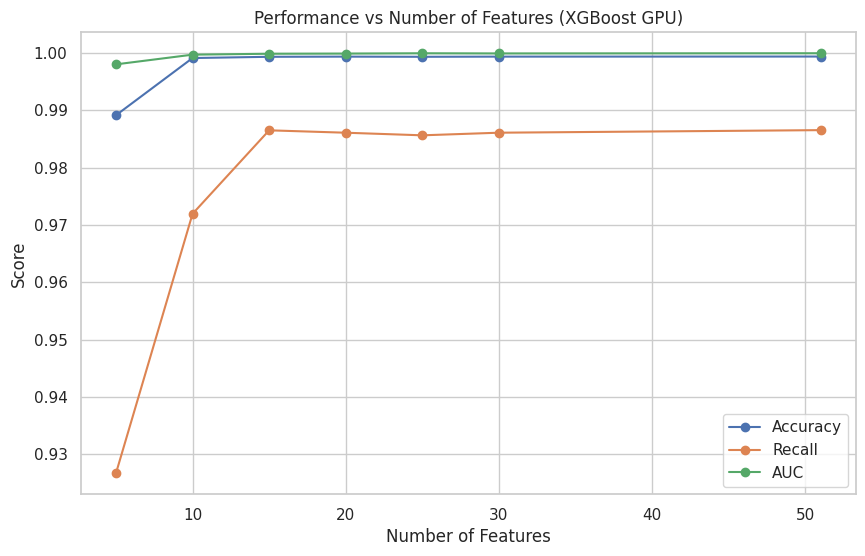


Determining optimal N using <1% improvement rule...

+5 feature improvement table:


,acc_gain,rec_gain
5,0.009974,0.045237
10,0.000218,0.014557
15,0.000029,-0.000418
20,-0.000029,-0.000454
25,0.000029,0.000457



📌 Recommended N: 15 features

✅ Saved feature_ranking.csv and feature_selection_results.csv to 01eda/
📌 Recommended N features: 15
📝 Ordered features: ['Fwd Header Len', 'Protocol', 'Init Bwd Win Byts', 'Tot Fwd Pkts', 'Pkt Len Max', 'Pkt Len Mean', 'Tot Bwd Pkts', 'Dst Port', 'Bwd Pkt Len Max', 'Fwd Pkts/s', 'Flow IAT Max', 'TotLen Bwd Pkts', 'TotLen Fwd Pkts', 'Bwd Pkt Len Std', 'Bwd Pkt Len Mean', 'Bwd IAT Std', 'Pkt Len Std', 'Bwd IAT Tot', 'Flow IAT Min', 'Flow IAT Std']...


In [10]:
from eda_utils import feature_selection_pipeline
import pandas as pd
import os

# Load the cleaned data
df = pd.read_csv("01eda/cleaned_data52.csv")
print(f"Loaded data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Run feature selection pipeline (handles label encoding internally)
out = feature_selection_pipeline(df, label_encoder_path="encoders/label_encoder.pkl")

# Save results to 01eda folder
os.makedirs("01eda", exist_ok=True)
out['rank_df'].to_csv("01eda/feature_ranking.csv")
out['results_df'].to_csv("01eda/feature_selection_results.csv")
print(f"\n✅ Saved feature_ranking.csv and feature_selection_results.csv to 01eda/")
print(f"📌 Recommended N features: {out['recommended_n']}")
print(f"📝 Ordered features: {out['ordered_features'][:20]}...")

In [11]:
# Save cleaned datasets with selected features
import os
import pickle

# Get recommended N and features
recommended_n = out['recommended_n']  # 15
ordered_features = out['ordered_features']

# Create cleaned datasets for recommended N features
top_n_features = ordered_features[:recommended_n]
print(f"Top {recommended_n} features: {top_n_features}")

# Load original cleaned data
df_full = pd.read_csv("01eda/cleaned_data52.csv")

# Create dataset with top N features + Label
selected_cols = top_n_features + ['Label']
df_n = df_full[selected_cols]

# Save datasets
df_n.to_csv(f"01eda/cleaned_data{recommended_n}.csv", index=False)
print(f"\n✅ Saved 01eda/cleaned_data{recommended_n}.csv with shape {df_n.shape}")

# Also save the feature list for reference
with open(f"01eda/top{recommended_n}_features.pkl", "wb") as f:
    pickle.dump(top_n_features, f)
print(f"✅ Saved 01eda/top{recommended_n}_features.pkl")

# Save full ordered features for later use
with open("01eda/ordered_features_all.pkl", "wb") as f:
    pickle.dump(ordered_features, f)
print("✅ Saved 01eda/ordered_features_all.pkl")

# Display summary
print(f"\n📊 Feature Selection Summary:")
print(f"   Total features available: 51")
print(f"   Recommended N: {recommended_n}")
print(f"   Dataset shape: {df_n.shape}")

Top 15 features: ['Fwd Header Len', 'Protocol', 'Init Bwd Win Byts', 'Tot Fwd Pkts', 'Pkt Len Max', 'Pkt Len Mean', 'Tot Bwd Pkts', 'Dst Port', 'Bwd Pkt Len Max', 'Fwd Pkts/s', 'Flow IAT Max', 'TotLen Bwd Pkts', 'TotLen Fwd Pkts', 'Bwd Pkt Len Std', 'Bwd Pkt Len Mean']

✅ Saved 01eda/cleaned_data15.csv with shape (343889, 16)
✅ Saved 01eda/top15_features.pkl
✅ Saved 01eda/ordered_features_all.pkl

📊 Feature Selection Summary:
   Total features available: 51
   Recommended N: 15
   Dataset shape: (343889, 16)


## End of Part 1
---
Cleaned datasets saved to 01eda/cleaned_data15.csv
> Load `01eda/cleaned_data52.csv` or `01eda/cleaned_data15.csv` for next part to skip running Part 1 again.

## Part 2: CTGAN Augmentation + Balancing Pipeline
**Goal**: Create a balanced dataset by:
1. **Generate 5000 synthetic samples** per minority class (CTGAN can generate more than original size)
2. **Filter synthetic samples** to keep only high-quality ones (NN distance + feature bounds)
3. **Undersample majority classes** using cluster-based sampling to preserve diversity
4. **Save one balanced dataset** to `02ctgan/balanced_15features.csv`
5. **Visualize** the data balance and synthetic quality

In [1]:
# Part 2 Setup - Import utilities
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Reload ctgan_utils to pick up any changes
import ctgan_utils
importlib.reload(ctgan_utils)

from ctgan_utils import (
    train_and_generate_ctgan,
    filter_synthetic_samples,
    undersample_majority_classes,
    create_balanced_dataset,
    plot_data_balance,
    plot_synthetic_quality,
    plot_feature_distributions
)

# Output directory
CTGAN_DIR = "02ctgan"
os.makedirs(CTGAN_DIR, exist_ok=True)

# Load label encoder
with open("encoders/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

print("Label classes:", label_encoder.classes_)
print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i}: {cls}")

Label classes: ['BFA' 'BOTNET' 'DDoS' 'DoS' 'Normal' 'Probe' 'U2R' 'Web-Attack']

Label mapping:
  0: BFA
  1: BOTNET
  2: DDoS
  3: DoS
  4: Normal
  5: Probe
  6: U2R
  7: Web-Attack


In [2]:
# Load the 15-feature dataset
df_15 = pd.read_csv("01eda/cleaned_data15.csv")
print(f"Loaded 15-feature dataset: {df_15.shape}")
print(f"\nOriginal Class Distribution:")
class_dist = df_15['Label'].value_counts()
for cls, cnt in class_dist.items():
    print(f"  {cls}: {cnt:,}")

# Identify minority classes (less than median count)
median_count = class_dist.median()
minority_classes = class_dist[class_dist < median_count].index.tolist()
majority_classes = class_dist[class_dist >= median_count].index.tolist()

print(f"\nMedian count: {median_count:,.0f}")
print(f"Minority classes: {minority_classes}")
print(f"Majority classes: {majority_classes}")

Loaded 15-feature dataset: (343889, 16)

Original Class Distribution:
  DDoS: 121,942
  Probe: 98,129
  Normal: 68,424
  DoS: 53,616
  BFA: 1,405
  Web-Attack: 192
  BOTNET: 164
  U2R: 17

Median count: 27,510
Minority classes: ['BFA', 'Web-Attack', 'BOTNET', 'U2R']
Majority classes: ['DDoS', 'Probe', 'Normal', 'DoS']


In [3]:
# Step 1: Generate 5000 synthetic samples per minority class
# CTGAN can generate more samples than original - conditioning helps quality

GENERATE_PER_CLASS = 5000  # Generate many, will filter later
quality_scores = {}
all_synthetic = []

print("="*60)
print("STEP 1: CTGAN Synthetic Data Generation")
print("="*60)

for label in minority_classes:
    print(f"\n{'─'*50}")
    print(f"Class: {label}")
    print(f"{'─'*50}")
    
    synthetic_df, quality = train_and_generate_ctgan(
        df=df_15,
        label_value=label,
        generate_samples=GENERATE_PER_CLASS,
        epochs=300,
        cuda=True
    )
    
    if not synthetic_df.empty:
        all_synthetic.append(synthetic_df)
        quality_scores[label] = quality
        print(f"  Generated: {len(synthetic_df)} samples, Quality: {quality:.4f}")
    else:
        print(f"  ⚠ Failed to generate for {label}")

# Combine all synthetic data
if all_synthetic:
    df_synthetic_raw = pd.concat(all_synthetic, ignore_index=True)
    print(f"\n✅ Total raw synthetic samples: {len(df_synthetic_raw)}")
else:
    df_synthetic_raw = pd.DataFrame()
    print("\n⚠ No synthetic data generated")

STEP 1: CTGAN Synthetic Data Generation

──────────────────────────────────────────────────
Class: BFA
──────────────────────────────────────────────────
  Real data size for 'BFA': 1405 samples
  Generating 5000 synthetic samples...
  Attempt 1/3 - epochs: 300
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 77.46it/s]|
Column Shapes Score: 75.79%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 502.25it/s]|
Column Pair Trends Score: 66.47%

Overall Score (Average): 71.13%

  ✅ Attempt 1: quality=0.7113
  ✅ Accepted (meets min quality 0.7)
  Generated: 5000 samples, Quality: 0.7113

──────────────────────────────────────────────────
Class: Web-Attack
──────────────────────────────────────────────────
  Real data size for 'Web-Attack': 192 samples
  Generating 5000 synthetic samples...
  Attempt 1/3 - epochs: 300
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 519.78it/s]|
Column Shap

In [4]:
# Step 2: Filter synthetic samples to keep high-quality ones
print("="*60)
print("STEP 2: Filtering Synthetic Samples")
print("="*60)

df_synthetic_filtered, filter_stats = filter_synthetic_samples(
    synthetic_df=df_synthetic_raw,
    real_df=df_15,
    label_col="Label",
    max_samples_per_class=3000  # Keep up to 3000 high-quality samples per class
)

print(f"\nFiltering Summary:")
for label, stats in filter_stats.get('per_class', {}).items():
    retention = stats['output'] / stats['input'] * 100 if stats['input'] > 0 else 0
    print(f"  {label}: {stats['input']} -> {stats['output']} ({retention:.1f}% retained)")

STEP 2: Filtering Synthetic Samples

Filtering Synthetic Samples
  Input: 20000 samples

  Class 'BFA': 5000 synthetic samples
    After NN filter: 4000 (80.0%)
    After bounds filter: 4000 (80.0%)
    After capping: 3000

  Class 'Web-Attack': 5000 synthetic samples
    After NN filter: 4000 (80.0%)
    After bounds filter: 4000 (80.0%)
    After capping: 3000

  Class 'BOTNET': 5000 synthetic samples
    After NN filter: 4000 (80.0%)
    After bounds filter: 4000 (80.0%)
    After capping: 3000

  Class 'U2R': 5000 synthetic samples
    After NN filter: 4000 (80.0%)
    After bounds filter: 4000 (80.0%)
    After capping: 3000

  ✅ Total filtered: 12000 samples (60.0% retained)

Filtering Summary:
  BFA: 5000 -> 3000 (60.0% retained)
  Web-Attack: 5000 -> 3000 (60.0% retained)
  BOTNET: 5000 -> 3000 (60.0% retained)
  U2R: 5000 -> 3000 (60.0% retained)


In [9]:
# Step 3: Hybrid Undersampling + Augmentation with Synthetic Data
print("="*60)
print("STEP 3: Hybrid Undersampling & Augmentation")
print("="*60)

# Reference target for augmentation (minority classes will be boosted toward this)
TARGET_PER_CLASS = 5000

# Step 3a: Apply hybrid undersampling (removes redundancy, preserves diversity)
# This does NOT cut to a fixed target - it removes duplicates and dense redundant samples
df_undersampled = undersample_majority_classes(
    df=df_15,
    label_col="Label", 
    target_per_class=TARGET_PER_CLASS,  # Used as reference, not strict cutoff
    method="hybrid"  # New hybrid method
)

# Step 3b: Augment minority classes with filtered synthetic data
df_balanced = create_balanced_dataset(
    original_df=df_undersampled,
    synthetic_df=df_synthetic_filtered,
    label_col="Label",
    target_per_class=TARGET_PER_CLASS
)

# Save the balanced dataset (single source of truth)
balanced_path = f"{CTGAN_DIR}/balanced_15features.csv"
df_balanced.to_csv(balanced_path, index=False)
print(f"\n📁 Saved balanced dataset to {balanced_path}")
print(f"   Shape: {df_balanced.shape}")

STEP 3: Hybrid Undersampling & Augmentation

CONSERVATIVE HYBRID UNDERSAMPLING (Redundancy Removal Only)

⚙️  Configuration:
    minimum_keep_ratio = 0.7 (keep ≥70%)
    minimum_keep_absolute = 40,000 (never below this)
    near_duplicate_precision = 3
    density_prune_fraction = 0.1 (≤10% density removal)

📊 Original Distribution:
    DDoS: 121,942 (min retain: 85,359)
    Probe: 98,129 (min retain: 68,690)
    Normal: 68,424 (min retain: 47,896)
    DoS: 53,616 (min retain: 40,000)
    BFA: 1,405 (min retain: 1,405)
    Web-Attack: 192 (min retain: 192)
    BOTNET: 164 (min retain: 164)
    U2R: 17 (min retain: 17)
    ────────────────────────────────────────
    Total: 343,889

  🔒 U2R: 17 -> 17 (protected - below 40,000)

  🔒 BFA: 1,405 -> 1,405 (protected - below 40,000)

  📉 DDoS: Processing 121,942 samples (min: 85,359)...
      Duplicates removed: 36,583
      Dense redundant removed: 0
      Final: 121,942 -> 85,359 (30.0% reduced)
      ⚠️  Minimum threshold applied (kept ≥8

STEP 4: Visualization

📊 Class Distribution Comparison:
  Saved plot to 02ctgan/class_balance_comparison.png


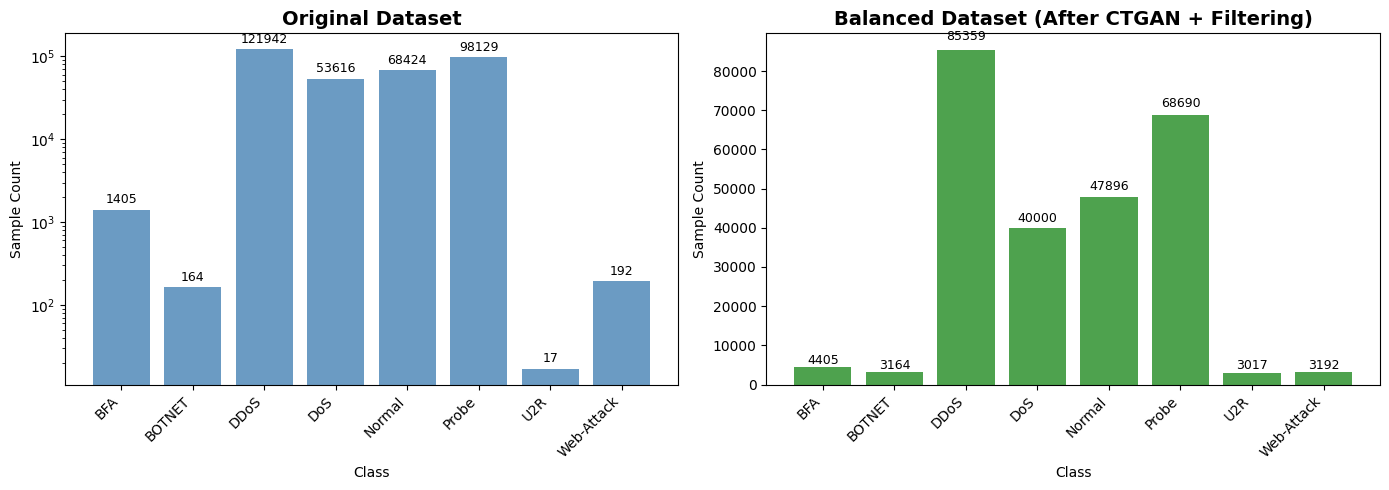

In [6]:
# Step 4: Visualize Data Balance
print("="*60)
print("STEP 4: Visualization")
print("="*60)

# Plot 1: Before vs After class distribution
print("\n📊 Class Distribution Comparison:")
fig1 = plot_data_balance(
    original_df=df_15,
    balanced_df=df_balanced,
    label_col="Label",
    save_path=f"{CTGAN_DIR}/class_balance_comparison.png"
)


📊 CTGAN Quality Scores by Class:
  Saved plot to 02ctgan/synthetic_quality_scores.png


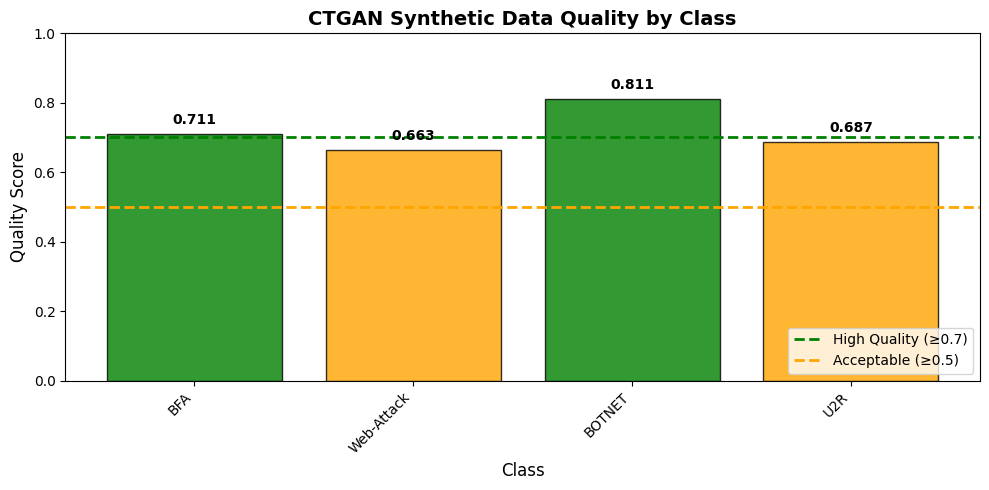

In [7]:
# Plot 2: Synthetic Data Quality Scores
print("\n📊 CTGAN Quality Scores by Class:")
fig2 = plot_synthetic_quality(
    quality_scores=quality_scores,
    save_path=f"{CTGAN_DIR}/synthetic_quality_scores.png"
)


📊 Feature Distributions: Real vs Synthetic:
  Saved plot to 02ctgan/feature_distribution_comparison.png


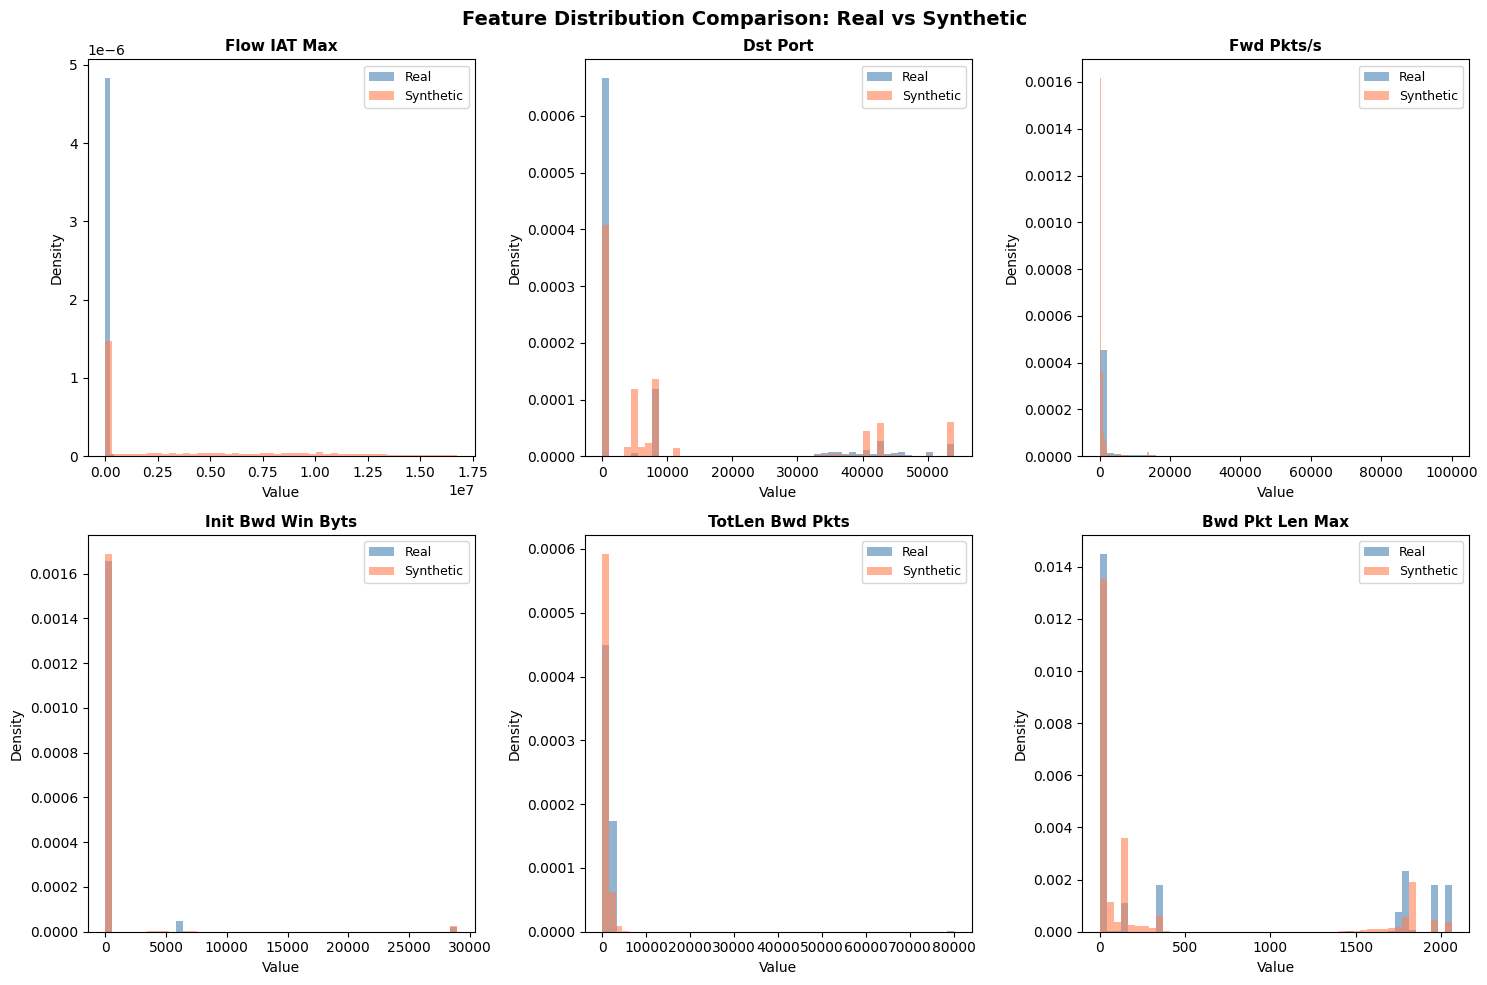

In [8]:
# Plot 3: Feature Distribution Comparison (Real vs Synthetic for minority classes)
print("\n📊 Feature Distributions: Real vs Synthetic:")

# Get only minority class data for comparison
real_minority = df_15[df_15['Label'].isin(minority_classes)]
syn_minority = df_synthetic_filtered[df_synthetic_filtered['Label'].isin(minority_classes)] if not df_synthetic_filtered.empty else pd.DataFrame()

if not syn_minority.empty:
    fig3 = plot_feature_distributions(
        real_df=real_minority,
        synthetic_df=syn_minority,
        label_col="Label",
        n_features=6,
        save_path=f"{CTGAN_DIR}/feature_distribution_comparison.png"
    )
else:
    print("  No synthetic data to compare")

In [10]:
# Part 2 Summary
print("="*60)
print("PART 2 SUMMARY: Hybrid Undersampling + CTGAN Augmentation")
print("="*60)

print("\n📊 Original Dataset:")
print(f"   Total samples: {len(df_15):,}")
print(f"   Classes: {df_15['Label'].nunique()}")
orig_dist = df_15['Label'].value_counts()
print(f"   Imbalance ratio: {orig_dist.max() / orig_dist.min():.1f}x")

print("\n🔬 Synthetic Data Generation (CTGAN):")
print(f"   Minority classes augmented: {len(minority_classes)}")
print(f"   Raw synthetic samples: {len(df_synthetic_raw):,}")
print(f"   Filtered synthetic samples: {len(df_synthetic_filtered):,}")
print(f"   Retention rate: {len(df_synthetic_filtered)/len(df_synthetic_raw)*100:.1f}%")

print("\n📉 Hybrid Undersampling:")
print(f"   After redundancy removal: {len(df_undersampled):,}")
print(f"   Reduction: {(1 - len(df_undersampled)/len(df_15))*100:.1f}%")

print("\n⚖️ Final Augmented Dataset:")
print(f"   Total samples: {len(df_balanced):,}")
bal_dist = df_balanced['Label'].value_counts()
print(f"   Imbalance ratio: {bal_dist.max() / bal_dist.min():.1f}x")
print(f"\n   Class distribution:")
for cls in sorted(bal_dist.index, key=lambda x: bal_dist[x], reverse=True):
    orig_cnt = orig_dist.get(cls, 0)
    new_cnt = bal_dist[cls]
    change = "↑" if new_cnt > orig_cnt else "↓" if new_cnt < orig_cnt else "="
    print(f"     {cls}: {new_cnt:,} ({change} from {orig_cnt:,})")

print("\n📈 Quality Scores (CTGAN):")
for cls, score in quality_scores.items():
    status = "✅" if score >= 0.7 else "⚠️" if score >= 0.5 else "❌"
    print(f"   {status} {cls}: {score:.4f}")

print(f"\n📁 Saved Files:")
for f in sorted(os.listdir(CTGAN_DIR)):
    fpath = os.path.join(CTGAN_DIR, f)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"   {f} ({size_mb:.2f} MB)")

PART 2 SUMMARY: Hybrid Undersampling + CTGAN Augmentation

📊 Original Dataset:
   Total samples: 343,889
   Classes: 8
   Imbalance ratio: 7173.1x

🔬 Synthetic Data Generation (CTGAN):
   Minority classes augmented: 4
   Raw synthetic samples: 20,000
   Filtered synthetic samples: 12,000
   Retention rate: 60.0%

📉 Hybrid Undersampling:
   After redundancy removal: 243,723
   Reduction: 29.1%

⚖️ Final Augmented Dataset:
   Total samples: 255,723
   Imbalance ratio: 28.3x

   Class distribution:
     DDoS: 85,359 (↓ from 121,942)
     Probe: 68,690 (↓ from 98,129)
     Normal: 47,896 (↓ from 68,424)
     DoS: 40,000 (↓ from 53,616)
     BFA: 4,405 (↑ from 1,405)
     Web-Attack: 3,192 (↑ from 192)
     BOTNET: 3,164 (↑ from 164)
     U2R: 3,017 (↑ from 17)

📈 Quality Scores (CTGAN):
   ✅ BFA: 0.7113
   ⚠️ Web-Attack: 0.6631
   ✅ BOTNET: 0.8112
   ⚠️ U2R: 0.6866

📁 Saved Files:
   balanced_15features.csv (16.66 MB)
   class_balance_comparison.png (0.09 MB)
   feature_distribution_compar

## End of Part 2
---
**Completed:**
- ✅ Generated 5000 synthetic samples per minority class using CTGAN
- ✅ Filtered synthetic samples to keep high-quality ones (NN distance + feature bounds)
- ✅ Undersampled majority classes using cluster-based sampling
- ✅ Created balanced dataset with ~5000 samples per class
- ✅ Visualized class distribution, quality scores, and feature distributions

**Saved to `02ctgan/`:**
- `balanced_15features.csv` — Balanced training dataset (use this for scaler/training)
- `class_balance_comparison.png` — Before/after distribution plot
- `synthetic_quality_scores.png` — CTGAN quality by class
- `feature_distribution_comparison.png` — Real vs synthetic features

> Load `02ctgan/balanced_15features.csv` for next part


## Part 3: Tri-Channel Scaler

This part builds the **Tri-Channel Scaler**, a pre-training artifact that converts
raw CICFlow features into an environment-invariant representation.

The scaler is:
- Fitted **once**
- Based on **benign traffic only**
- Saved and reused for **all models and inference**

In [1]:
import pandas as pd
import os

# Use balanced dataset from Part 2
DATA_PATH = "02ctgan/balanced_15features.csv"
SCALER_PATH = "scalers/trichannel_scaler.pkl"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Balanced dataset not found at {DATA_PATH}. Run Part 2 first.")

df = pd.read_csv(DATA_PATH)
print("Label distribution:")
print(df["Label"].value_counts())

Label distribution:
Label
DDoS          85359
Probe         68690
Normal        47896
DoS           40000
BFA            4405
Web-Attack     3192
BOTNET         3164
U2R            3017
Name: count, dtype: int64


### Fit Tri-Channel Scaler (Benign-Only Statistics)

In [2]:
from scaler_utils import TriChannelScaler

FEATURE_COLS = [c for c in df.columns if c != "Label"]

scaler = TriChannelScaler(
    benign_label="Normal",  # Fit on benign traffic only
    epsilon=1e-6
)

scaler.fit(
    df[FEATURE_COLS],
    labels=df["Label"]
)

### Save Scaler Artifact

In [3]:
import joblib

os.makedirs("scalers", exist_ok=True)
joblib.dump(scaler, SCALER_PATH)

print(f"Tri-Channel scaler saved to {SCALER_PATH}")

Tri-Channel scaler saved to scalers/trichannel_scaler.pkl


### Verify Transformation Shape

In [4]:
import warnings

X_tri = scaler.transform(df[FEATURE_COLS])
print("Original shape:", df[FEATURE_COLS].shape)
print("Tri-Channel shape:", X_tri.shape)
#  Tri-Channel shape = (N, 15 × 3 = 45)

Original shape: (255723, 15)
Tri-Channel shape: (255723, 45)


## End of Part 3
---
**Completed:**
- ✅ Fitted Tri-Channel scaler on benign (Normal) traffic using balanced data
- ✅ Saved scaler artifact for reuse
- ✅ Verified tri-channel output shape (15 features -> 45 channels)

**Saved to `scalers/`:**
- `trichannel_scaler.pkl` — Tri-Channel scaler for training/inference

> Load `02ctgan/balanced_15features.csv` and `scalers/trichannel_scaler.pkl` for downstream training


## Part 4: Model Training

### 4.1: Binary Detection Core
It consists of two independent models trained on Tri-Channel features (45 features):
1. Isolation Forest
    - Unsupervised
    - Benign-only
    - Zero-day safety net
2. XGBoost Binary
    - Supervised  
    - Known-attack detector
    - Fast & precise

**Note:** We use the pre-trained `TriChannelScaler` to convert the 15 raw features into 45 tri-channel features (Log, Ratio, Delta) before training. This ensures the models learn environment-agnostic patterns.

In [1]:
# --- STEP 1: LOAD & SCALE (Tri-Channel) ---
import pandas as pd
import joblib
from scaler_utils import TriChannelScaler

# Load raw datasets
df_orig = pd.read_csv('01eda/cleaned_data15.csv')
df_balanced = pd.read_csv('02ctgan/balanced_15features.csv')

# Load EXISTING Tri-Channel Scaler (DO NOT FIT NEW ONE)
try:
    scaler = joblib.load('scalers/trichannel_scaler.pkl')
    print("Loaded existing TriChannelScaler from scalers/trichannel_scaler.pkl")
except FileNotFoundError:
    raise RuntimeError("TriChannelScaler not found in scalers/trichannel_scaler.pkl. Please ensure it exists.")

# Transform to tri-channel (15 -> 45) and keep labels attached
print("Transforming datasets to 45 features...")
X_orig_scaled = scaler.transform(df_orig.drop(columns=['Label']))
df_orig_scaled = pd.concat([X_orig_scaled, df_orig['Label']], axis=1)

X_bal_scaled = scaler.transform(df_balanced.drop(columns=['Label']))
df_bal_scaled = pd.concat([X_bal_scaled, df_balanced['Label']], axis=1)

print(f"Transformation complete. Shapes: {df_orig_scaled.shape}, {df_bal_scaled.shape}")

Loaded existing TriChannelScaler from scalers/trichannel_scaler.pkl
Transforming datasets to 45 features...
Transformation complete. Shapes: (343889, 46), (255723, 46)


In [ ]:
from anomaly_utils import SafetyNet
import os

# Train SafetyNet on tri-channel scaled original data
if 'df_orig_scaled' not in globals():
    raise RuntimeError("Scaled dataframe not found. Run the load & scale cell first.")

feat_cols = [c for c in df_orig_scaled.columns if c != 'Label']
safety_net = SafetyNet(label_col='Label', features=feat_cols)

search_info_sn = safety_net.fit_with_split_search(
    df_orig_scaled,
    seeds=(42, 52, 62),
    normal_label='Normal',
    val_size=0.2,
    )
print('SafetyNet best split:', search_ info_sn)

os.makedirs('models/safetynet', exist_ok=True)
safety_net.save('models/safetynet/safety_net_v1.pkl')

[Info] SafetyNet loaded scaler from scalers/trichannel_scaler.pkl
[-] Starting Split Search on 343889 samples...
   [Seed 42] F1: 0.0000 | AUC: 0.8813
   [Seed 52] F1: 0.0000 | AUC: 0.8775
   [Seed 62] F1: 0.0006 | AUC: 0.8844
[+] Best Split Found: Seed 62 (F1=0.0006)
SafetyNet best split: {'best_seed': 62, 'metrics': {'f1': 0.0006151174150595217, 'auc': 0.8844302696033804, 'precision': 0.09392265193370165, 'recall': 0.0003085691467155537}}
[+] Safety Net saved to models/safety_net_v1.pkl


SafetyNet anomaly-score AUC on CTGAN-balanced: 0.8517


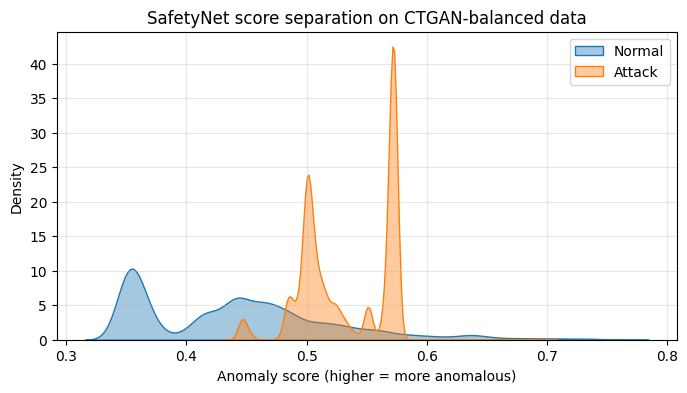

In [3]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_auc_score

# Evaluate SafetyNet (trained on tri-channel data) against CTGAN-balanced dataset
df_ctgan = pd.read_csv('02ctgan/balanced_15features.csv')
y_binary = (df_ctgan['Label'] != 'Normal').astype(int)

if 'safety_net' not in globals():
    raise RuntimeError("SafetyNet not found in memory. Run the SafetyNet training cell first.")

# Ensure scaler is available
if 'scaler' not in globals():
    scaler = joblib.load('scalers/trichannel_scaler.pkl')

# Tri-channel scale the CTGAN set
X_ctgan_scaled = scaler.transform(df_ctgan.drop(columns=['Label']))
df_ctgan_scaled = pd.concat([X_ctgan_scaled, df_ctgan['Label']], axis=1)
feat_cols = getattr(safety_net, 'features', [c for c in df_ctgan_scaled.columns if c != 'Label'])

# Score CTGAN-balanced set (higher score -> more anomalous)
scores = safety_net.model.score_samples(df_ctgan_scaled[feat_cols])
anomaly_scores = -scores  # lower raw score = more anomalous -> invert for intuition

# AUC using anomaly scores
auc_sn = roc_auc_score(y_binary, anomaly_scores)
print(f"SafetyNet anomaly-score AUC on CTGAN-balanced: {auc_sn:.4f}")

# Plot score distributions
plt.figure(figsize=(8,4))
sns.kdeplot(anomaly_scores[y_binary==0], label='Normal', fill=True, alpha=0.4)
sns.kdeplot(anomaly_scores[y_binary==1], label='Attack', fill=True, alpha=0.4)
plt.xlabel('Anomaly score (higher = more anomalous)')
plt.title('SafetyNet score separation on CTGAN-balanced data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


[~] Evaluating split train/val/test=0.70/0.15/0.15 seed=42
[-] Initializing XGBoost (GPU: ON, Tree: Hist)...
[-] Training started...


/home/fyp2025/fyp/backend/fypenv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [18:29:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[+] Training complete. Trees trained: 400
    Metrics (seed 42): {'accuracy': 0.9996871659845147, 'precision': 0.999615224292173, 'recall': 1.0, 'f1': 0.9998075751258779, 'auc': 0.9999574792419401}

[~] Evaluating split train/val/test=0.70/0.15/0.15 seed=52


/home/fyp2025/fyp/backend/fypenv/lib/python3.12/site-packages/xgboost/core.py:774: UserWarning: [18:29:28] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[-] Initializing XGBoost (GPU: ON, Tree: Hist)...
[-] Training started...


...

[+] Training complete. Trees trained: 400
    Metrics (seed 42): {'accuracy': 0.9996741269861961, 'precision': 0.9996472493466095, 'recall': 0.999951882979406, 'f1': 0.9997995429579442, 'auc': 0.9999795346112212}

[~] Evaluating split train/val/test=0.40/0.30/0.30 seed=52
[-] Initializing XGBoost (GPU: ON, Tree: Hist)...
[-] Training started...


/home/fyp2025/fyp/backend/fypenv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [18:29:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[+] Training complete. Trees trained: 400
    Metrics (seed 52): {'accuracy': 0.9998435809533741, 'precision': 0.999823599217422, 'recall': 0.9999839609931354, 'f1': 0.9999037736756852, 'auc': 0.9999883036583317}

[~] Evaluating split train/val/test=0.40/0.30/0.30 seed=62
[-] Initializing XGBoost (GPU: ON, Tree: Hist)...
[-] Training started...


/home/fyp2025/fyp/backend/fypenv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [18:29:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[+] Training complete. Trees trained: 400
    Metrics (seed 62): {'accuracy': 0.999752336509509, 'precision': 0.9998075473513705, 'recall': 0.9998877269519472, 'f1': 0.9998476355442217, 'auc': 0.9999980873520591}

[+] Best split (0.6, 0.2, 0.2) seed=62 auc=1.0000
XGB best split: {'best_seed': 62, 'best_split': (0.6, 0.2, 0.2), 'best_score': 0.9999998141454006, 'metrics': {'accuracy': 0.9997849252126307, 'precision': 0.9997594708358388, 'recall': 0.9999759418755714, 'f1': 0.9998676946392273, 'auc': 0.9999998141454006}}

=== XGBoost Evaluation ===
              precision    recall  f1-score   support

           0     0.9999    0.9990    0.9994      9579
           1     0.9998    1.0000    0.9999     41566

    accuracy                         0.9998     51145
   macro avg     0.9998    0.9995    0.9996     51145
weighted avg     0.9998    0.9998    0.9998     51145

ROC-AUC: 1.0000


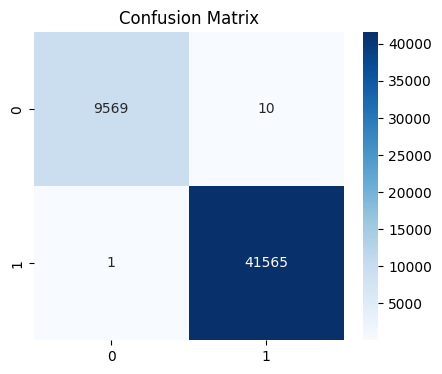

[+] Model saved to models/xgb_binary_v1.json


In [ ]:
import pandas as pd
import importlib
import joblib
import xgb_utils
import os

# Reload to pick up latest code
importlib.reload(xgb_utils)
XGBDetector = xgb_utils.XGBDetector

# Ensure tri-channel scaled balanced dataset is available
if 'df_bal_scaled' not in globals():
    scaler = joblib.load('scalers/trichannel_scaler.pkl')
    df_balanced = pd.read_csv('02ctgan/balanced_15features.csv')
    X_bal_scaled = scaler.transform(df_balanced.drop(columns=['Label']))
    df_bal_scaled = pd.concat([X_bal_scaled, df_balanced['Label']], axis=1)

X = df_bal_scaled.drop(columns=['Label'])
y = (df_bal_scaled['Label'] != 'Normal').astype(int)

# Splits to compare (train, val, test)
split_grid = [
    (0.70, 0.15, 0.15),
    (0.60, 0.20, 0.20),
    (0.50, 0.25, 0.25),
    (0.40, 0.30, 0.30),
]

xgb_det = XGBDetector()
search_info_xgb = xgb_det.train_with_split_search(
    X,
    y,
    seeds=(42, 52, 62),
    val_size=0.15,  # ignored when split_grid is provided
    test_size=0.15, # ignored when split_grid is provided
    patience=30,
    metric='auc',
    stratify_labels=df_bal_scaled['Label'],
    split_grid=split_grid,
    )
print('XGB best split:', search_info_xgb)

# Evaluate on the best split's test set
if getattr(xgb_det, 'best_data', None) is not None:
    X_test, y_test = xgb_det.best_data
    xgb_det.evaluate(X_test, y_test)

# Save the best model
os.makedirs('models/xgb', exist_ok=True)
xgb_det.save('models/xgb/xgb_binary_v1.json')

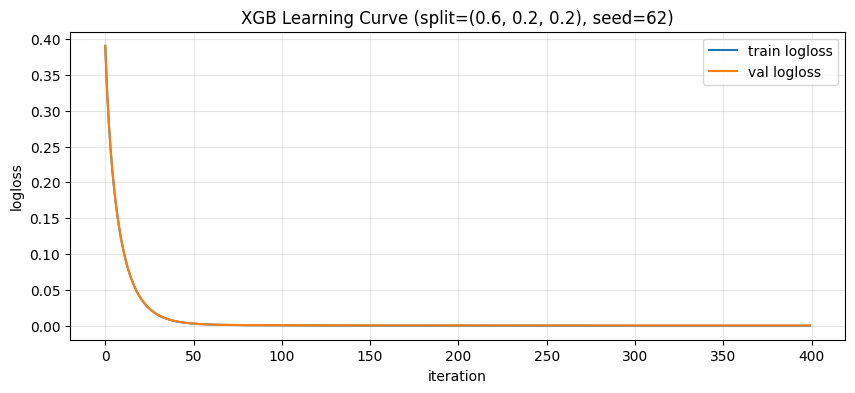

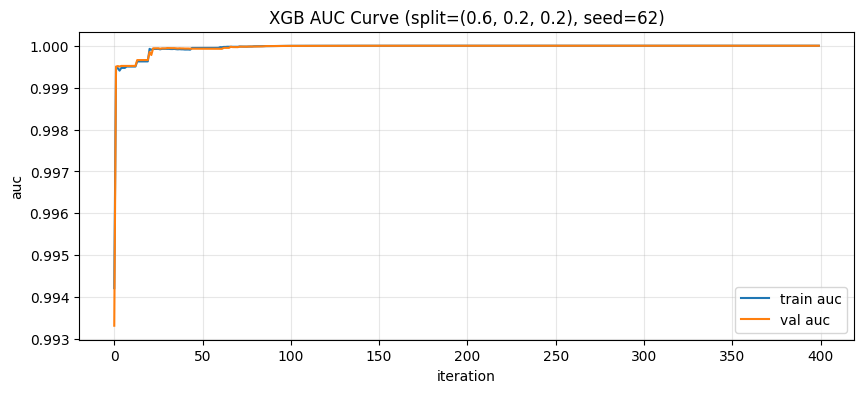

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot learning curves for the best XGB run
try:
    det = xgb_det
except NameError:
    print("xgb_det not found. Run the XGB training cell above first.")
else:
    if getattr(det, 'evals_result', None):
        res = det.evals_result
        epochs = range(len(res['validation_0']['logloss']))
        plt.figure(figsize=(10,4))
        plt.plot(epochs, res['validation_0']['logloss'], label='train logloss')
        plt.plot(epochs, res['validation_1']['logloss'], label='val logloss')
        plt.xlabel('iteration')
        plt.ylabel('logloss')
        plt.title(f"XGB Learning Curve (split={det.best_split}, seed={det.best_seed})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(10,4))
        plt.plot(epochs, res['validation_0']['auc'], label='train auc')
        plt.plot(epochs, res['validation_1']['auc'], label='val auc')
        plt.xlabel('iteration')
        plt.ylabel('auc')
        plt.title(f"XGB AUC Curve (split={det.best_split}, seed={det.best_seed})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("No evals_result found to plot learning curves.")

### 4.2: GNN Training
**Goal**: Train and select the best GNN model for attack detection using 15 physics-normalized features.
**Strategies**: Compare GraphSAGE vs GAT, and different graph construction methods (KNN, Temporal, Hybrid).
**Metrics**: Attack Recall, FPR (Normal), Stability.


In [1]:
import torch
import pandas as pd
import numpy as np
import importlib
import gnn_utils
import os
import json

# Reload utils
importlib.reload(gnn_utils)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load Data (Recovers IPs/Time and selects 15 features)
# This might take a minute
df_gnn, feature_cols, label_encoder = gnn_utils.load_gnn_data()

print(f"Data loaded: {df_gnn.shape}")
print(f"Features: {len(feature_cols)}")
print(f"Classes: {label_encoder.classes_}")


/home/fyp2025/fyp/backend/fypenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Loading raw data to recover topology...
Loaded metasploitable-2.csv with shape (136743, 84)
Loaded OVS.csv with shape (138722, 84)
Loaded Normal_data.csv with shape (68424, 84)
Selected 15 features: ['Fwd Header Len', 'Protocol', 'Init Bwd Win Byts', 'Tot Fwd Pkts', 'Pkt Len Max', 'Pkt Len Mean', 'Tot Bwd Pkts', 'Dst Port', 'Bwd Pkt Len Max', 'Fwd Pkts/s', 'Flow IAT Max', 'TotLen Bwd Pkts', 'TotLen Fwd Pkts', 'Bwd Pkt Len Std', 'Bwd Pkt Len Mean']
Parsing timestamps...
Scaling features (standard)...
Data loaded: (343889, 20)
Features: 15
Classes: ['BFA' 'BOTNET' 'DDoS' 'DoS' 'Normal' 'Probe' 'U2R' 'Web-Attack']


In [2]:
# Define Experiments
architectures = ['sage', 'gat']
strategies = ['knn_protocol', 'src_ip_temporal', 'hybrid'] # 'dst_ip_temporal' might be too dense/slow, sticking to requested ones + hybrid
splits = [
    (0.70, 0.15, 0.15),
    (0.80, 0.10, 0.10),
    (0.60, 0.20, 0.20)
]

# Hyperparams grid (simplified for runtime, can expand)
# The user asked to vary hidden_dim, num_layers, dropout.
# We will pick a few combinations or loop all.
# To save time, we'll test 2 configs per arch.
configs = [
    {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3},
    {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.5}
]

results = []
best_model_score = -1 # Based on Recall - FPR? Or just Recall?
# User: "Highest Attack Recall, Lowest False Positive Rate"
# We can use a composite score: Recall - FPR (max 1)
best_model_info = {}
best_model_state = None

# Directory for models
os.makedirs('models/gnn', exist_ok=True)

# We need to build graphs for each strategy ONCE to save time
# But splits change masks.
graphs = {}

for strategy in strategies:
    print(f"\nBuilding graph for strategy: {strategy}...")
    try:
        data = gnn_utils.build_graph(df_gnn, feature_cols, strategy=strategy)
        data = data.to(device)
        graphs[strategy] = data
    except Exception as e:
        print(f"Failed to build graph for {strategy}: {e}")

print("\nGraphs built. Starting training loop...")



Building graph for strategy: knn_protocol...
Building graph with strategy: knn_protocol
  Constructing Protocol-aware KNN edges...
  Graph created: 343889 nodes, 1719445 edges

Building graph for strategy: src_ip_temporal...
Building graph with strategy: src_ip_temporal
  Constructing SrcIP Temporal edges...
  Graph created: 343889 nodes, 130022 edges

Building graph for strategy: hybrid...
Building graph with strategy: hybrid
  Constructing Protocol-aware KNN edges...
  Constructing SrcIP Temporal edges...
  Constructing DstIP/Port edges...
  Graph created: 343889 nodes, 1994811 edges

Graphs built. Starting training loop...


In [3]:
import time
import copy
from sklearn.model_selection import train_test_split

# Define Experiments
architectures = ['sage', 'gat']
strategies = ['knn_protocol', 'src_ip_temporal', 'hybrid']
splits = [
    (0.70, 0.15, 0.15),
    (0.80, 0.10, 0.10),
    (0.60, 0.20, 0.20)
]
configs = [
    {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3},
    {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.5}
]
tasks = ['binary', 'multiclass']

results = []

best_binary_score = -float('inf')
best_multiclass_score = -float('inf')

best_binary_state = None
best_multiclass_state = None

best_binary_info = {}
best_multiclass_info = {}

# Ensure directory exists
os.makedirs('models/gnn/gnn_learning_curves', exist_ok=True)

# Loop over experiments
for task in tasks:
    print(f"\n=== Starting Task: {task.upper()} ===")
    
    for strategy, original_data in graphs.items():
        # Prepare Data for Task
        data = original_data.clone()
        
        if task == 'binary':
            # Map Normal -> 0, Attack -> 1
            normal_idx = label_encoder.transform(['Normal'])[0]
            # Create binary labels: 0 if Normal, 1 if Attack
            # Note: original_data.y contains encoded labels.
            # We want Normal(0) and Attack(1).
            # So if y == normal_idx -> 0, else -> 1
            data.y = (original_data.y != normal_idx).long()
            num_classes = 2
            is_binary = True
        else:
            # Multiclass
            num_classes = len(label_encoder.classes_)
            is_binary = False
            
        data = data.to(device)
        
        for arch in architectures:
            for config in configs:
                for split in splits:
                    train_ratio, val_ratio, test_ratio = split
                    
                    model_id = f"{task}_{strategy}_{arch}_h{config['hidden_dim']}_l{config['num_layers']}_{int(train_ratio*100)}"
                    print(f"\n--- Model: {model_id} ---")
                    
                    # Create masks (Stratified)
                    num_nodes = data.num_nodes
                    indices = np.arange(num_nodes)
                    y_cpu = data.y.cpu().numpy()
                    
                    try:
                        train_idx, temp_idx = train_test_split(
                            indices, train_size=train_ratio, stratify=y_cpu, random_state=42
                        )
                        val_ratio_adj = val_ratio / (val_ratio + test_ratio)
                        val_idx, test_idx = train_test_split(
                            temp_idx, train_size=val_ratio_adj, stratify=y_cpu[temp_idx], random_state=42
                        )
                    except ValueError as e:
                        print(f"Skipping split due to stratification error (too few samples per class?): {e}")
                        continue
                    
                    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
                    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
                    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
                    
                    train_mask[train_idx] = True
                    val_mask[val_idx] = True
                    test_mask[test_idx] = True
                    
                    # Class Weights
                    y_train = y_cpu[train_idx]
                    classes_in_train = np.unique(y_train)
                    class_weights = torch.tensor(
                        [len(y_train) / (len(classes_in_train) * np.sum(y_train == c)) for c in range(num_classes)],
                        dtype=torch.float
                    ).to(device)
                    
                    # Initialize Model
                    model = gnn_utils.GNNClassifier(
                        input_dim=len(feature_cols),
                        hidden_dim=config['hidden_dim'],
                        num_classes=num_classes,
                        num_layers=config['num_layers'],
                        dropout=config['dropout'],
                        arch=arch
                    ).to(device)
                    
                    # Train
                    start_time = time.time()
                    history = gnn_utils.train_gnn(
                        model, data, train_mask.to(device), val_mask.to(device),
                        epochs=50, # Keep low for demo, increase for real
                        patience=5,
                        class_weights=class_weights
                    )
                    training_time = time.time() - start_time
                    
                    # Plot Learning Curve
                    plot_filename = f"models/gnn/gnn_learning_curves/{model_id}.png"
                    gnn_utils.plot_gnn_learning_curve(history, f"Learning Curve: {model_id}", plot_filename)
                    
                    # Evaluate
                    metrics = gnn_utils.evaluate_gnn(model, data, test_mask.to(device), label_encoder, is_binary_task=is_binary)
                    
                    # Add to results
                    res_entry = {
                        'model_id': model_id,
                        'task': task,
                        'strategy': strategy,
                        'arch': arch,
                        'split': split,
                        'config': config,
                        'best_epoch': len(history['train_loss']) - 5, # Approx
                        'val_f1': -1, # Not returned by train_gnn, but we have history['val_loss']
                        'test_f1': metrics['f1_binary'] if is_binary else metrics['macro_f1'],
                        'attack_recall': metrics['recall_attack'],
                        'fpr': metrics['fpr_normal'],
                        'macro_f1': metrics['macro_f1'],
                        'training_time': training_time
                    }
                    results.append(res_entry)
                    
                    print(f"  Stats: Recall={metrics['recall_attack']:.4f}, FPR={metrics['fpr_normal']:.4f}, Time={training_time:.2f}s")
                    
                    # Selection Logic
                    if task == 'binary':
                        # Score: Recall - FPR (Maximize this)
                        # Also check stability (not implemented strictly, but early stopping helps)
                        score = metrics['recall_attack'] - metrics['fpr_normal']
                        if score > best_binary_score:
                            best_binary_score = score
                            best_binary_state = copy.deepcopy(model.state_dict())
                            best_binary_info = res_entry
                            print("  >>> New Best Binary Model!")
                            
                    else: # Multiclass
                        # Score: Macro F1
                        score = metrics['macro_f1']
                        if score > best_multiclass_score:
                            best_multiclass_score = score
                            best_multiclass_state = copy.deepcopy(model.state_dict())
                            best_multiclass_info = res_entry
                            print("  >>> New Best Multiclass Model!")

# Save Comparison Table
results_df = pd.DataFrame(results)
results_df.to_csv('models/gnn/gnn_model_comparison.csv', index=False)
print("\n=== Training Complete ===")
print("Comparison table saved to models/gnn/gnn_model_comparison.csv")

# Display Table
display(results_df.sort_values(by=['task', 'test_f1'], ascending=False))

# Save Best Models
if best_binary_state:
    torch.save(best_binary_state, 'models/gnn/best_binary_gnn.pt')
    with open('models/gnn/best_binary_config.json', 'w') as f:
        json.dump({
            'info': best_binary_info,
            'features': feature_cols
        }, f, indent=4)
    print(f"\nSaved Best Binary Model (Score={best_binary_score:.4f})")

if best_multiclass_state:
    torch.save(best_multiclass_state, 'models/gnn/best_multiclass_gnn.pt')
    with open('models/gnn/best_multiclass_config.json', 'w') as f:
        json.dump({
            'info': best_multiclass_info,
            'features': feature_cols
        }, f, indent=4)
    print(f"Saved Best Multiclass Model (Score={best_multiclass_score:.4f})")

# Justification
print("\n=== Justification ===")
print(f"Best Binary Model: {best_binary_info.get('model_id')} selected for high Attack Recall ({best_binary_info.get('attack_recall'):.4f}) and low FPR ({best_binary_info.get('fpr'):.4f}).")
print(f"Best Multiclass Model: {best_multiclass_info.get('model_id')} selected for highest Macro-F1 ({best_multiclass_info.get('macro_f1'):.4f}).")


=== Starting Task: BINARY ===

--- Model: binary_knn_protocol_sage_h64_l2_70 ---
Epoch 000: Train Loss: 0.7446, Val Loss: 0.5464
Epoch 010: Train Loss: 0.1514, Val Loss: 0.1215
Epoch 020: Train Loss: 0.0607, Val Loss: 0.0523
Epoch 030: Train Loss: 0.0561, Val Loss: 0.0487
Epoch 040: Train Loss: 0.0502, Val Loss: 0.0430
Saved plot to models/gnn/gnn_learning_curves/binary_knn_protocol_sage_h64_l2_70.png
  Stats: Recall=0.9969, FPR=0.0200, Time=3.14s
  >>> New Best Binary Model!

--- Model: binary_knn_protocol_sage_h64_l2_80 ---
Epoch 000: Train Loss: 0.6141, Val Loss: 0.4649
Epoch 010: Train Loss: 0.0760, Val Loss: 0.0733
Epoch 020: Train Loss: 0.0594, Val Loss: 0.0600
Early stopping at epoch 27
Saved plot to models/gnn/gnn_learning_curves/binary_knn_protocol_sage_h64_l2_80.png
  Stats: Recall=0.9975, FPR=0.0178, Time=0.40s
  >>> New Best Binary Model!

--- Model: binary_knn_protocol_sage_h64_l2_60 ---
Epoch 000: Train Loss: 0.6984, Val Loss: 0.5076
Epoch 010: Train Loss: 0.1054, Val Lo

,model_id,task,strategy,arch,split,config,best_epoch,val_f1,test_f1,attack_recall,fpr,macro_f1,training_time
51,multiclass_src_ip_temporal_sage_h128_l3_70,multiclass,src_ip_temporal,sage,"(0.7, 0.15, 0.15)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",45,-1,0.598308,0.999056,0.018219,0.598308,1.431625
52,multiclass_src_ip_temporal_sage_h128_l3_80,multiclass,src_ip_temporal,sage,"(0.8, 0.1, 0.1)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",45,-1,0.573385,0.999347,0.018998,0.573385,1.438719
65,multiclass_hybrid_sage_h128_l3_60,multiclass,hybrid,sage,"(0.6, 0.2, 0.2)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",45,-1,0.573035,0.998911,0.010522,0.573035,2.810797
53,multiclass_src_ip_temporal_sage_h128_l3_60,multiclass,src_ip_temporal,sage,"(0.6, 0.2, 0.2)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",45,-1,0.568667,0.999256,0.015711,0.568667,1.426144
63,multiclass_hybrid_sage_h128_l3_70,multiclass,hybrid,sage,"(0.7, 0.15, 0.15)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",45,-1,0.565391,0.998984,0.010620,0.565391,2.817971
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,binary_knn_protocol_gat_h128_l3_60,binary,knn_protocol,gat,"(0.6, 0.2, 0.2)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",12,-1,0.995507,0.995480,0.017976,0.988712,1.524162
15,binary_src_ip_temporal_sage_h128_l3_70,binary,src_ip_temporal,sage,"(0.7, 0.15, 0.15)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",14,-1,0.994896,0.993030,0.012958,0.987271,0.529084
17,binary_src_ip_temporal_sage_h128_l3_60,binary,src_ip_temporal,sage,"(0.6, 0.2, 0.2)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",14,-1,0.994422,0.991796,0.011765,0.986130,0.528081
16,binary_src_ip_temporal_sage_h128_l3_80,binary,src_ip_temporal,sage,"(0.8, 0.1, 0.1)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",11,-1,0.993037,0.988819,0.010814,0.982797,0.446455



Saved Best Binary Model (Score=0.9934)
Saved Best Multiclass Model (Score=0.5983)

=== Justification ===
Best Binary Model: binary_hybrid_gat_h64_l2_80 selected for high Attack Recall (0.9979) and low FPR (0.0045).
Best Multiclass Model: multiclass_src_ip_temporal_sage_h128_l3_70 selected for highest Macro-F1 (0.5983).


### 4.3: GNN Training with RobustScaler
**Goal**: Repeat GNN training comparison but using `RobustScaler` instead of `StandardScaler`.
`RobustScaler` is less sensitive to outliers, which might improve performance on attack data with extreme values.

In [4]:
import torch
import pandas as pd
import numpy as np
import importlib
import gnn_utils
import os
import json

# Reload utils
importlib.reload(gnn_utils)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load Data with RobustScaler
df_gnn_robust, feature_cols_robust, label_encoder_robust = gnn_utils.load_gnn_data(scaler_type='robust')

print(f"Robust Data loaded: {df_gnn_robust.shape}")


Using device: cuda
Loading raw data to recover topology...
Loaded metasploitable-2.csv with shape (136743, 84)
Loaded OVS.csv with shape (138722, 84)
Loaded Normal_data.csv with shape (68424, 84)
Selected 15 features: ['Fwd Header Len', 'Protocol', 'Init Bwd Win Byts', 'Tot Fwd Pkts', 'Pkt Len Max', 'Pkt Len Mean', 'Tot Bwd Pkts', 'Dst Port', 'Bwd Pkt Len Max', 'Fwd Pkts/s', 'Flow IAT Max', 'TotLen Bwd Pkts', 'TotLen Fwd Pkts', 'Bwd Pkt Len Std', 'Bwd Pkt Len Mean']
Parsing timestamps...
Scaling features (robust)...
Robust Data loaded: (343889, 20)


In [5]:
# Reuse experiment definitions from previous section
architectures = ['sage', 'gat']
strategies = ['knn_protocol', 'src_ip_temporal', 'hybrid']
splits = [
    (0.70, 0.15, 0.15),
    (0.80, 0.10, 0.10),
    (0.60, 0.20, 0.20)
]

# Build graphs for robust data
graphs_robust = {}

for strategy in strategies:
    print(f"\nBuilding robust graph for strategy: {strategy}...")
    try:
        data = gnn_utils.build_graph(df_gnn_robust, feature_cols_robust, strategy=strategy)
        data = data.to(device)
        graphs_robust[strategy] = data
    except Exception as e:
        print(f"Failed to build graph for {strategy}: {e}")

print("\nRobust Graphs built. Ready for training.")


Building robust graph for strategy: knn_protocol...
Building graph with strategy: knn_protocol
  Constructing Protocol-aware KNN edges...
  Graph created: 343889 nodes, 1719445 edges

Building robust graph for strategy: src_ip_temporal...
Building graph with strategy: src_ip_temporal
  Constructing SrcIP Temporal edges...
  Graph created: 343889 nodes, 130022 edges

Building robust graph for strategy: hybrid...
Building graph with strategy: hybrid
  Constructing Protocol-aware KNN edges...
  Constructing SrcIP Temporal edges...
  Constructing DstIP/Port edges...
  Graph created: 343889 nodes, 1995313 edges

Robust Graphs built. Ready for training.


In [6]:
import time
import copy
from sklearn.model_selection import train_test_split

# Configs
# We use same configs as before
configs = [
    {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3},
    {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.5}
]
tasks = ['binary', 'multiclass']

results_robust = []

best_binary_score_robust = -float('inf')
best_multiclass_score_robust = -float('inf')

best_binary_state_robust = None
best_multiclass_state_robust = None

best_binary_info_robust = {}
best_multiclass_info_robust = {}

# Ensure directory exists
os.makedirs('models/gnn_robust/learning_curves', exist_ok=True)

# Loop over experiments
for task in tasks:
    print(f"\n=== Starting Task (Robust): {task.upper()} ===")
    
    for strategy, original_data in graphs_robust.items():
        # Prepare Data for Task
        data = original_data.clone()
        
        if task == 'binary':
            # Map Normal -> 0, Attack -> 1
            normal_idx = label_encoder_robust.transform(['Normal'])[0]
            data.y = (original_data.y != normal_idx).long()
            num_classes = 2
            is_binary = True
        else:
            # Multiclass
            num_classes = len(label_encoder_robust.classes_)
            is_binary = False
            
        data = data.to(device)
        
        for arch in architectures:
            for config in configs:
                for split in splits:
                    train_ratio, val_ratio, test_ratio = split
                    
                    model_id = f"robust_{task}_{strategy}_{arch}_h{config['hidden_dim']}_l{config['num_layers']}_{int(train_ratio*100)}"
                    print(f"\n--- Model: {model_id} ---")
                    
                    # Create masks (Stratified)
                    num_nodes = data.num_nodes
                    indices = np.arange(num_nodes)
                    y_cpu = data.y.cpu().numpy()
                    
                    try:
                        train_idx, temp_idx = train_test_split(
                            indices, train_size=train_ratio, stratify=y_cpu, random_state=42
                        )
                        val_ratio_adj = val_ratio / (val_ratio + test_ratio)
                        val_idx, test_idx = train_test_split(
                            temp_idx, train_size=val_ratio_adj, stratify=y_cpu[temp_idx], random_state=42
                        )
                    except ValueError as e:
                        print(f"Skipping split due to stratification error: {e}")
                        continue
                    
                    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
                    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
                    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
                    
                    train_mask[train_idx] = True
                    val_mask[val_idx] = True
                    test_mask[test_idx] = True
                    
                    # Class Weights
                    y_train = y_cpu[train_idx]
                    classes_in_train = np.unique(y_train)
                    class_weights = torch.tensor(
                        [len(y_train) / (len(classes_in_train) * np.sum(y_train == c)) for c in range(num_classes)],
                        dtype=torch.float
                    ).to(device)
                    
                    # Initialize Model
                    model = gnn_utils.GNNClassifier(
                        input_dim=len(feature_cols_robust),
                        hidden_dim=config['hidden_dim'],
                        num_classes=num_classes,
                        num_layers=config['num_layers'],
                        dropout=config['dropout'],
                        arch=arch
                    ).to(device)
                    
                    # Train
                    start_time = time.time()
                    history = gnn_utils.train_gnn(
                        model, data, train_mask.to(device), val_mask.to(device),
                        epochs=50, 
                        patience=5,
                        class_weights=class_weights
                    )
                    training_time = time.time() - start_time
                    
                    # Plot Learning Curve
                    plot_filename = f"models/gnn_robust/learning_curves/{model_id}.png"
                    gnn_utils.plot_gnn_learning_curve(history, f"Learning Curve: {model_id}", plot_filename)
                    
                    # Evaluate
                    metrics = gnn_utils.evaluate_gnn(model, data, test_mask.to(device), label_encoder_robust, is_binary_task=is_binary)
                    
                    # Add to results
                    res_entry = {
                        'model_id': model_id,
                        'task': task,
                        'strategy': strategy,
                        'arch': arch,
                        'split': split,
                        'config': config,
                        'best_epoch': len(history['train_loss']) - 5,
                        'test_f1': metrics['f1_binary'] if is_binary else metrics['macro_f1'],
                        'attack_recall': metrics['recall_attack'],
                        'fpr': metrics['fpr_normal'],
                        'macro_f1': metrics['macro_f1'],
                        'training_time': training_time
                    }
                    results_robust.append(res_entry)
                    
                    print(f"  Stats: Recall={metrics['recall_attack']:.4f}, FPR={metrics['fpr_normal']:.4f}, Time={training_time:.2f}s")
                    
                    # Selection Logic
                    if task == 'binary':
                        score = metrics['recall_attack'] - metrics['fpr_normal']
                        if score > best_binary_score_robust:
                            best_binary_score_robust = score
                            best_binary_state_robust = copy.deepcopy(model.state_dict())
                            best_binary_info_robust = res_entry
                            print("  >>> New Best Binary Model (Robust)!")
                            
                    else: # Multiclass
                        score = metrics['macro_f1']
                        if score > best_multiclass_score_robust:
                            best_multiclass_score_robust = score
                            best_multiclass_state_robust = copy.deepcopy(model.state_dict())
                            best_multiclass_info_robust = res_entry
                            print("  >>> New Best Multiclass Model (Robust)!")

# Save Comparison Table
results_df_robust = pd.DataFrame(results_robust)
results_df_robust.to_csv('models/gnn_robust/gnn_model_comparison_robust.csv', index=False)
print("\n=== Training Complete (Robust) ===")
print("Comparison table saved to models/gnn_robust/gnn_model_comparison_robust.csv")

# Display Table
display(results_df_robust.sort_values(by=['task', 'test_f1'], ascending=False))

# Save Best Models
if best_binary_state_robust:
    torch.save(best_binary_state_robust, 'models/gnn_robust/best_binary_gnn_robust.pt')
    with open('models/gnn_robust/best_binary_config_robust.json', 'w') as f:
        json.dump({
            'info': best_binary_info_robust,
            'features': feature_cols_robust
        }, f, indent=4)
    print(f"\nSaved Best Binary Model (Robust) (Score={best_binary_score_robust:.4f})")

if best_multiclass_state_robust:
    torch.save(best_multiclass_state_robust, 'models/gnn_robust/best_multiclass_gnn_robust.pt')
    with open('models/gnn_robust/best_multiclass_config_robust.json', 'w') as f:
        json.dump({
            'info': best_multiclass_info_robust,
            'features': feature_cols_robust
        }, f, indent=4)
    print(f"Saved Best Multiclass Model (Robust) (Score={best_multiclass_score_robust:.4f})")


=== Starting Task (Robust): BINARY ===

--- Model: robust_binary_knn_protocol_sage_h64_l2_70 ---
Epoch 000: Train Loss: 116.5235, Val Loss: 21.8397
Epoch 010: Train Loss: 6.0683, Val Loss: 6.3293
Early stopping at epoch 12
Saved plot to models/gnn_robust/learning_curves/robust_binary_knn_protocol_sage_h64_l2_70.png
  Stats: Recall=0.9022, FPR=0.3406, Time=0.19s
  >>> New Best Binary Model (Robust)!

--- Model: robust_binary_knn_protocol_sage_h64_l2_80 ---
Epoch 000: Train Loss: 78.6985, Val Loss: 57.5471
Epoch 010: Train Loss: 8.9360, Val Loss: 4.8626
Early stopping at epoch 17
Saved plot to models/gnn_robust/learning_curves/robust_binary_knn_protocol_sage_h64_l2_80.png
  Stats: Recall=0.9442, FPR=0.4523, Time=0.26s

--- Model: robust_binary_knn_protocol_sage_h64_l2_60 ---
Epoch 000: Train Loss: 280.9858, Val Loss: 20.8539
Epoch 010: Train Loss: 11.1320, Val Loss: 7.7444
Epoch 020: Train Loss: 4.4349, Val Loss: 4.5302
Epoch 030: Train Loss: 2.8109, Val Loss: 3.6204
Early stopping at e

,model_id,task,strategy,arch,split,config,best_epoch,test_f1,attack_recall,fpr,macro_f1,training_time
61,robust_multiclass_hybrid_sage_h64_l2_80,multiclass,hybrid,sage,"(0.8, 0.1, 0.1)","{'hidden_dim': 64, 'num_layers': 2, 'dropout':...",45,0.467994,0.994482,0.023966,0.467994,0.814398
37,robust_multiclass_knn_protocol_sage_h64_l2_80,multiclass,knn_protocol,sage,"(0.8, 0.1, 0.1)","{'hidden_dim': 64, 'num_layers': 2, 'dropout':...",45,0.464763,0.986459,0.035657,0.464763,0.757973
49,robust_multiclass_src_ip_temporal_sage_h64_l2_80,multiclass,src_ip_temporal,sage,"(0.8, 0.1, 0.1)","{'hidden_dim': 64, 'num_layers': 2, 'dropout':...",45,0.450125,0.996116,0.033757,0.450125,0.401634
51,robust_multiclass_src_ip_temporal_sage_h128_l3_70,multiclass,src_ip_temporal,sage,"(0.7, 0.15, 0.15)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",45,0.411212,0.989351,0.107268,0.411212,1.422446
64,robust_multiclass_hybrid_sage_h128_l3_80,multiclass,hybrid,sage,"(0.8, 0.1, 0.1)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",45,0.392807,0.998802,0.239953,0.392807,2.800017
...,...,...,...,...,...,...,...,...,...,...,...,...
11,robust_binary_knn_protocol_gat_h128_l3_60,binary,knn_protocol,gat,"(0.6, 0.2, 0.2)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",12,0.853482,0.748425,0.021703,0.753812,1.523730
22,robust_binary_src_ip_temporal_gat_h128_l3_80,binary,src_ip_temporal,gat,"(0.8, 0.1, 0.1)","{'hidden_dim': 128, 'num_layers': 3, 'dropout'...",9,0.848660,0.805743,0.374836,0.684043,0.592114
18,robust_binary_src_ip_temporal_gat_h64_l2_70,binary,src_ip_temporal,gat,"(0.7, 0.15, 0.15)","{'hidden_dim': 64, 'num_layers': 2, 'dropout':...",5,0.820567,0.697144,0.008184,0.719161,0.127901
7,robust_binary_knn_protocol_gat_h64_l2_80,binary,knn_protocol,gat,"(0.8, 0.1, 0.1)","{'hidden_dim': 64, 'num_layers': 2, 'dropout':...",1,0.759133,0.611777,0.000000,0.660248,0.170662



Saved Best Binary Model (Robust) (Score=0.9702)
Saved Best Multiclass Model (Robust) (Score=0.4680)



🏆 BEST MULTICLASS GNN MODEL:
   ID:           multiclass_src_ip_temporal_sage_h128_l3_70
   Strategy:     src_ip_temporal
   Architecture: sage
   Split:        (0.7, 0.15, 0.15)
   Config:       {'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.5}
   Test F1:      0.59831


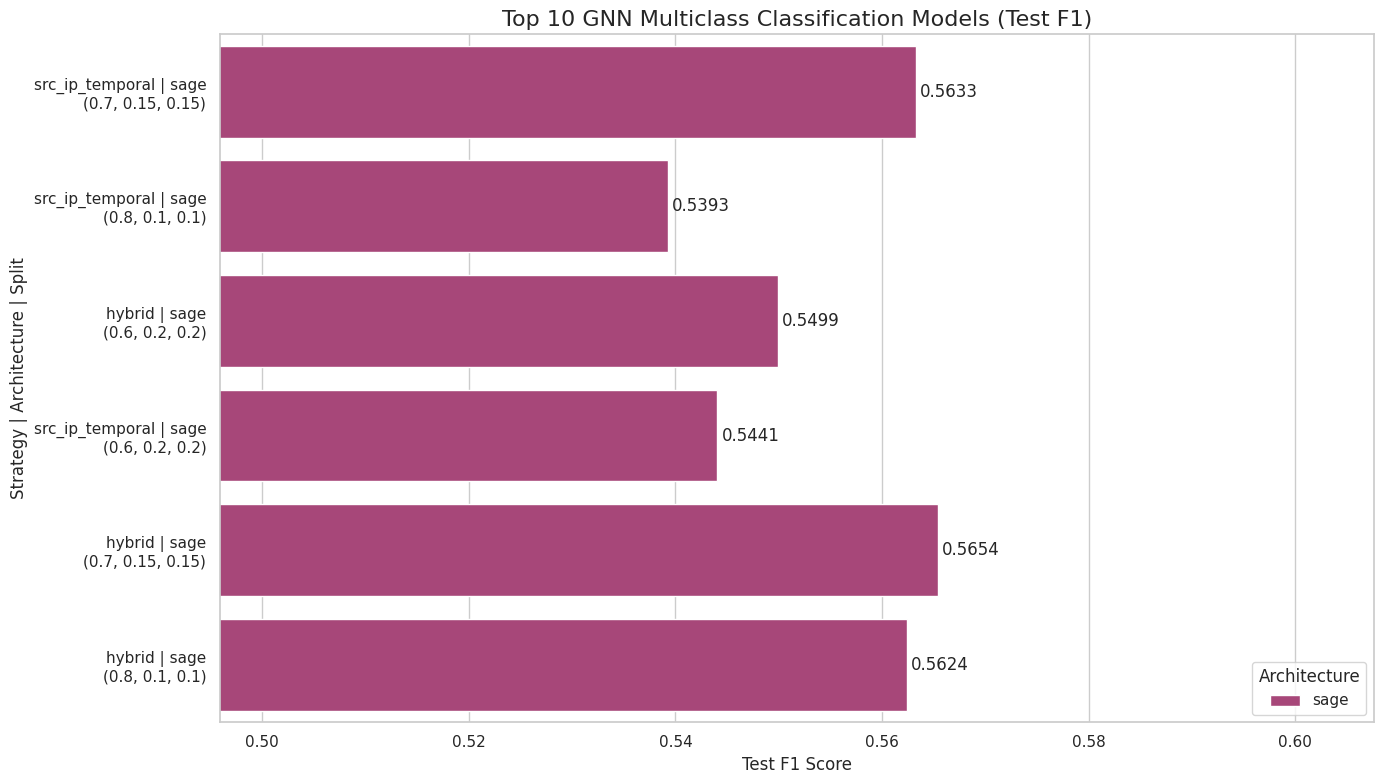

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define path to CSV
csv_path = 'models/gnn/gnn_model_comparison.csv'

if os.path.exists(csv_path):
    # Load the GNN model comparison data
    df = pd.read_csv(csv_path)
    
    # Set up the plotting style
    sns.set(style="whitegrid")
    
    # Filter for Multiclass tasks only
    multiclass_df = df[df['task'] == 'multiclass'].copy()
    
    if not multiclass_df.empty:
        # Create a figure with a single subplot
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Create a combined identifier for the x-axis to make it readable
        # Shows Strategy + Arch + Split
        multiclass_df['model_label'] = multiclass_df['strategy'] + " | " + multiclass_df['arch'] + "\n" + multiclass_df['split']
        
        # FILTER TOP 10 MODELS
        # Sort by F1 score descending to get the best ones, take top 10
        multiclass_df = multiclass_df.sort_values('test_f1', ascending=False).head(10)

        barplot = sns.barplot(
            data=multiclass_df, 
            y='model_label', 
            x='test_f1', 
            hue='arch', 
            ax=ax, 
            palette='magma',
            orient='h',
            errorbar=None # Remove the error bars (black lines)
        )
        ax.set_title('Top 10 GNN Multiclass Classification Models (Test F1)', fontsize=16)
        ax.set_ylabel('Strategy | Architecture | Split', fontsize=12)
        ax.set_xlabel('Test F1 Score', fontsize=12)
        
        # Adjust x-limit to focus on the performance range
        min_f1 = multiclass_df['test_f1'].min()
        max_f1 = multiclass_df['test_f1'].max()
        padding = (max_f1 - min_f1) * 0.1 if max_f1 > min_f1 else 0.05
        ax.set_xlim(max(0, min_f1 - padding), min(1.0, max_f1 + padding)) 
        
        ax.legend(title='Architecture', loc='lower right')
        
        # Annotate bars with values
        for container in ax.containers:
            ax.bar_label(container, fmt='%.4f', padding=3)

        # Find best multiclass model
        best_multiclass = multiclass_df.sort_values('test_f1', ascending=False).iloc[0]
        print("\n" + "="*60)
        print("🏆 BEST MULTICLASS GNN MODEL:")
        print(f"   ID:           {best_multiclass['model_id']}")
        print(f"   Strategy:     {best_multiclass['strategy']}")
        print(f"   Architecture: {best_multiclass['arch']}")
        print(f"   Split:        {best_multiclass['split']}")
        print(f"   Config:       {best_multiclass['config']}")
        print(f"   Test F1:      {best_multiclass['test_f1']:.5f}")
        print("="*60)
        
        plt.tight_layout()
        plt.show()
    else:
        print("No multiclass task data found in the CSV.")

else:
    print(f"File not found: {csv_path}")